# E-Commerce Sales Analysis

## Project Objective

The objective of this project is to analyze an e-commerce sales dataset to identify revenue trends, top-performing product categories, regional performance, customer reviews, and key business insights. The analysis helps businesses make data-driven decisions for improving sales and customer satisfaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Loading

In [2]:
customers = pd.read_csv("data/olist_customers_dataset.csv")

orders = pd.read_csv("data/olist_orders_dataset.csv")

items = pd.read_csv("data/olist_order_items_dataset.csv")

payments = pd.read_csv("data/olist_order_payments_dataset.csv")

reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

products = pd.read_csv("data/olist_products_dataset.csv")

sellers = pd.read_csv("data/olist_sellers_dataset.csv")

geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")

translation = pd.read_csv(
    "data/product_category_name_translation.csv"
)

print("\nDatasets Loaded Successfully!\n")

print("Customers Dataset :", customers.shape)
print("Orders Dataset    :", orders.shape)
print("Items Dataset     :", items.shape)
print("Payments Dataset  :", payments.shape)
print("Reviews Dataset   :", reviews.shape)
print("Products Dataset  :", products.shape)
print("Sellers Dataset   :", sellers.shape)
print("Geolocation Data  :", geolocation.shape)
print("Translation Data  :", translation.shape)


Datasets Loaded Successfully!

Customers Dataset : (99441, 5)
Orders Dataset    : (99441, 8)
Items Dataset     : (112650, 7)
Payments Dataset  : (103886, 5)
Reviews Dataset   : (99224, 7)
Products Dataset  : (32951, 9)
Sellers Dataset   : (3095, 4)
Geolocation Data  : (1000163, 5)
Translation Data  : (71, 2)


# Data Exploration & Cleaning

In [3]:
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers
}

for name, df in datasets.items():

    print(f"\n{name} Dataset")

    print("Shape:", df.shape)

    print("Missing Values:")
    print(df.isnull().sum().sum())

    print("Duplicate Rows:")
    print(df.duplicated().sum())


DATA CLEANING

Customers Dataset
Shape: (99441, 5)
Missing Values:
0
Duplicate Rows:
0

Orders Dataset
Shape: (99441, 8)
Missing Values:
4908
Duplicate Rows:
0

Items Dataset
Shape: (112650, 7)
Missing Values:
0
Duplicate Rows:
0

Payments Dataset
Shape: (103886, 5)
Missing Values:
0
Duplicate Rows:
0

Reviews Dataset
Shape: (99224, 7)
Missing Values:
145903
Duplicate Rows:
0

Products Dataset
Shape: (32951, 9)
Missing Values:
2448
Duplicate Rows:
0

Sellers Dataset
Shape: (3095, 4)
Missing Values:
0
Duplicate Rows:
0


# Dataset Summary

### Dataset Summary

- The Olist Brazilian E-Commerce dataset consists of multiple related datasets.
- Missing values and duplicate records were checked before analysis.
- Product categories were translated into English.
- The datasets were merged into a master dataset for analysis.
- The cleaned dataset is ready for business insights and visualization.

# Date Conversion

In [4]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

print("\nDate Conversion Completed Successfully!")

print("\nData Types:")
print(orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date"
]].dtypes)


Date Conversion Completed Successfully!

Data Types:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_customer_date    datetime64[us]
dtype: object


# Product Category Translation

In [7]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

print("Product Categories Translated Successfully!\n")

print(products.shape)

products[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head()

Product Categories Translated Successfully!

(32951, 12)


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares


# Master Dataset Creation

In [10]:
sales = items.merge(
    orders,
    on="order_id"
)

sales = sales.merge(
    customers,
    on="customer_id"
)

sales = sales.merge(
    products,
    on="product_id"
)

sales = sales.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

print("Master Dataset Created Successfully!\n")

print(sales.shape)

print(sales.columns.tolist())

Master Dataset Created Successfully!

(113314, 30)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english_x', 'product_category_name_english_y', 'product_category_name_english', 'review_score']


# Feature Engineering

In [11]:
sales["revenue"] = (
    sales["price"] +
    sales["freight_value"]
)

sales["month"] = (
    sales["order_purchase_timestamp"]
    .dt.month_name()
)

sales["year"] = (
    sales["order_purchase_timestamp"]
    .dt.year
)

print("\nFeature Engineering Completed!")

print("\nRevenue Statistics:")
print(sales["revenue"].describe())

print("\nYears Available:")
print(sales["year"].unique())


Feature Engineering Completed!

Revenue Statistics:
count    113314.000000
mean        140.458128
std         190.362183
min           6.080000
25%          55.180000
50%          92.205000
75%         157.790000
max        6929.310000
Name: revenue, dtype: float64

Years Available:
[2017 2018 2016]


# Sales Analysis

## Question 1

### Which product category generates the highest revenue?

In [12]:
top_category = (
    sales.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Revenue Categories:\n")

print(
    top_category.head(10)
)


Top 10 Revenue Categories:

product_category_name_english
health_beauty            1446622.08
watches_gifts            1306761.40
bed_bath_table           1258189.51
sports_leisure           1163329.98
computers_accessories    1068070.48
furniture_decor           910683.05
housewares                781170.03
cool_stuff                721492.90
auto                      687374.19
garden_tools              585646.54
Name: revenue, dtype: float64


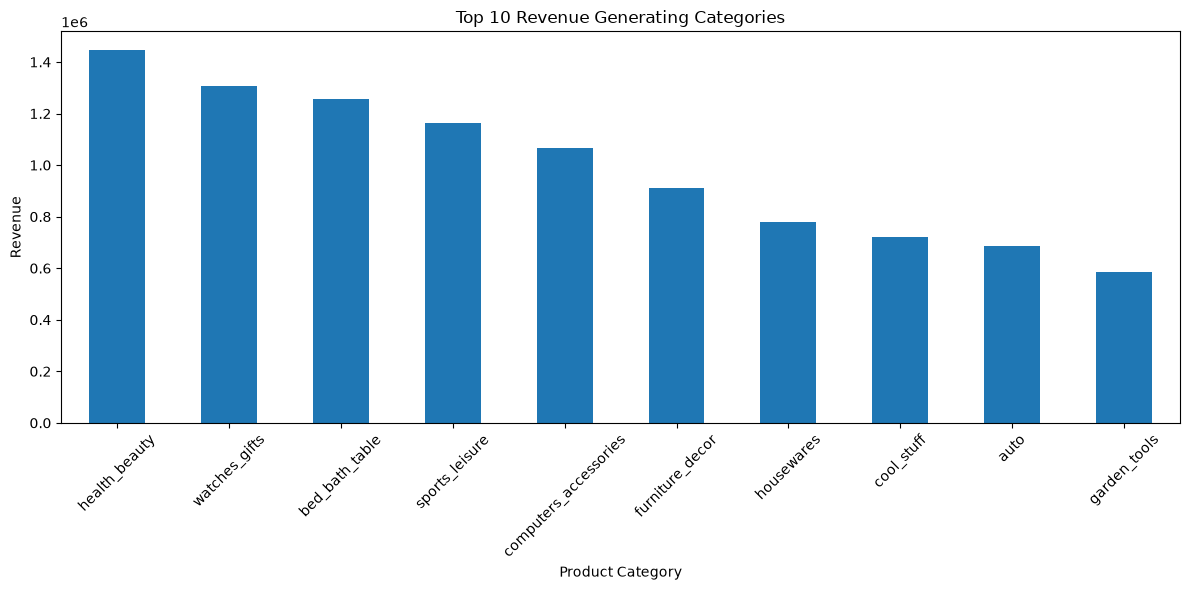

In [13]:
plt.figure(figsize=(12,6))

top_category.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Revenue Generating Categories"
)

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Question 2

### Which month had the highest sales?

In [14]:
monthly_sales = (
    sales.groupby("month")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nMonthly Revenue:\n")
print(monthly_sales)


Monthly Revenue:

month
May          1740991.24
August       1677209.15
July         1650171.28
March        1593708.92
April        1575614.49
June         1530797.72
February     1285836.31
January      1252089.23
November     1187779.95
December      866858.16
October       830994.70
September     723821.17
Name: revenue, dtype: float64


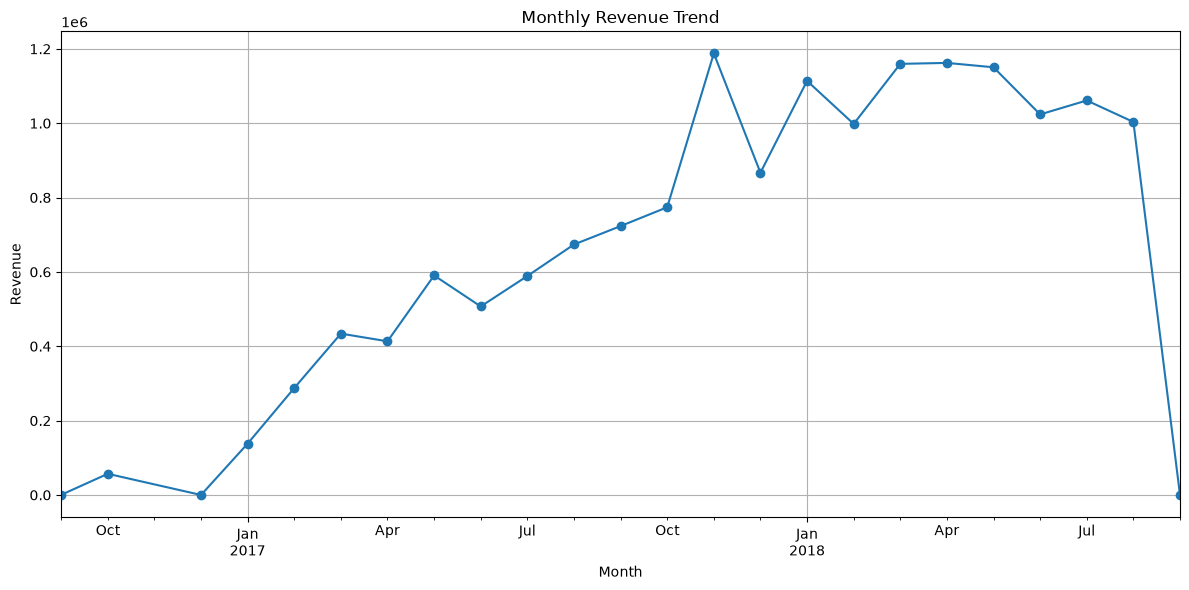

In [15]:
monthly_trend = (
    sales.groupby(
        sales["order_purchase_timestamp"]
        .dt.to_period("M")
    )["revenue"]
    .sum()
)

plt.figure(figsize=(12,6))

monthly_trend.plot(
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

## Question 3

### Which region (state) performs the best?

In [16]:
state_sales = (
    sales.groupby("customer_state")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 States by Revenue:\n")

print(
    state_sales.head(10)
)


Top 10 States by Revenue:

customer_state
SP    5951489.17
RJ    2139076.28
MG    1863794.44
RS     890763.29
PR     804321.70
BA     613777.23
SC     612153.65
DF     355792.69
GO     351160.09
ES     325949.95
Name: revenue, dtype: float64


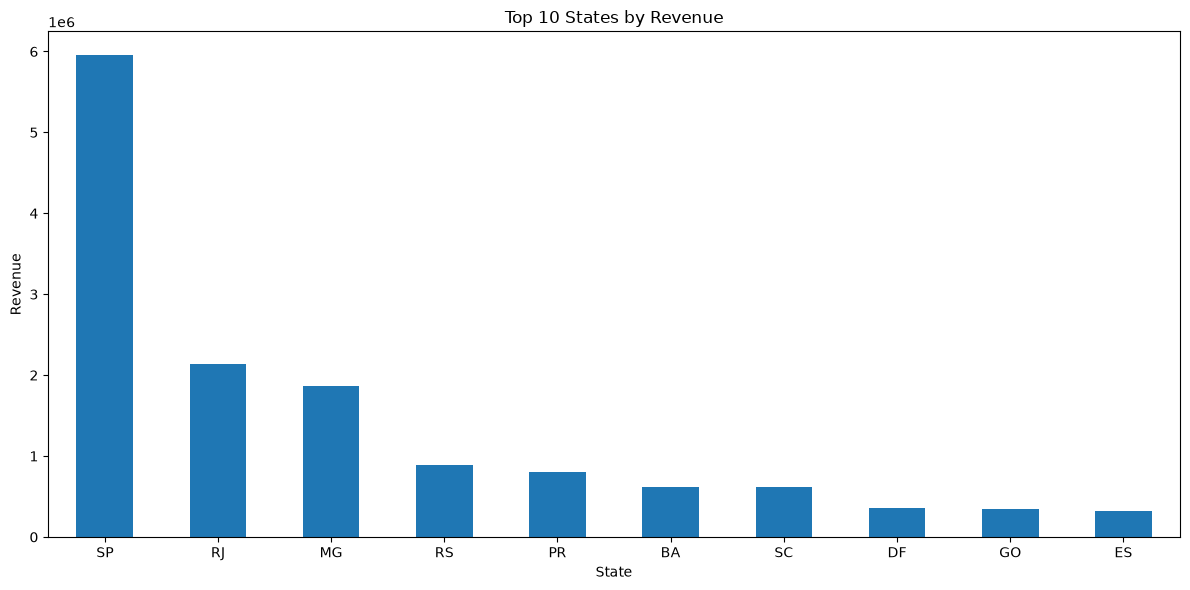

In [17]:
plt.figure(figsize=(12,6))

state_sales.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 States by Revenue"
)

plt.xlabel("State")

plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## Question 4

### What is the distribution of order values?

In [18]:
order_value = (
    sales.groupby("order_id")["revenue"]
    .sum()
)

average_order_value = round(
    order_value.mean(), 2
)

print("\nAverage Order Value:")

print(f"₹ {average_order_value}")

print("\nOrder Value Statistics:")

print(order_value.describe())


Average Order Value:
₹ 161.31

Order Value Statistics:
count    98666.000000
mean       161.310607
std        221.293040
min          9.590000
25%         62.150000
50%        105.665000
75%        177.490000
max      13664.080000
Name: revenue, dtype: float64


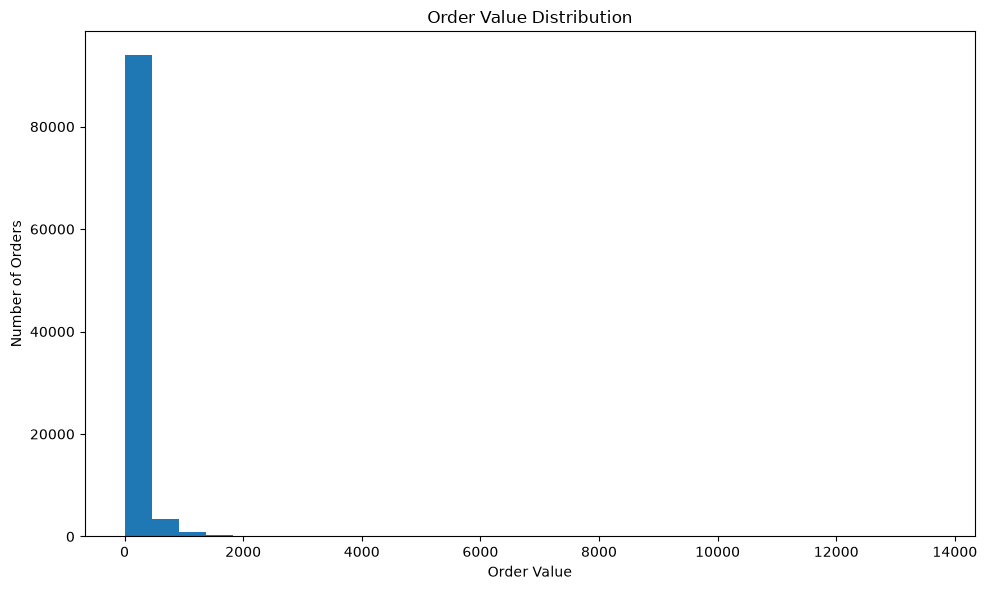

In [19]:
plt.figure(figsize=(10,6))

plt.hist(
    order_value,
    bins=30
)

plt.title(
    "Order Value Distribution"
)

plt.xlabel(
    "Order Value"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()

plt.savefig(
    "dashboard/order_value_distribution.png"
)

plt.show()

## Question 5

### What is the customer review score distribution?

In [20]:
review_distribution = (
    sales["review_score"]
    .value_counts()
    .sort_index()
)

print("\nCustomer Review Score Distribution:\n")

print(review_distribution)

average_review_score = round(
    sales["review_score"].mean(), 2
)

print(f"\nAverage Review Score : {average_review_score}")


Customer Review Score Distribution:

review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64

Average Review Score : 4.03


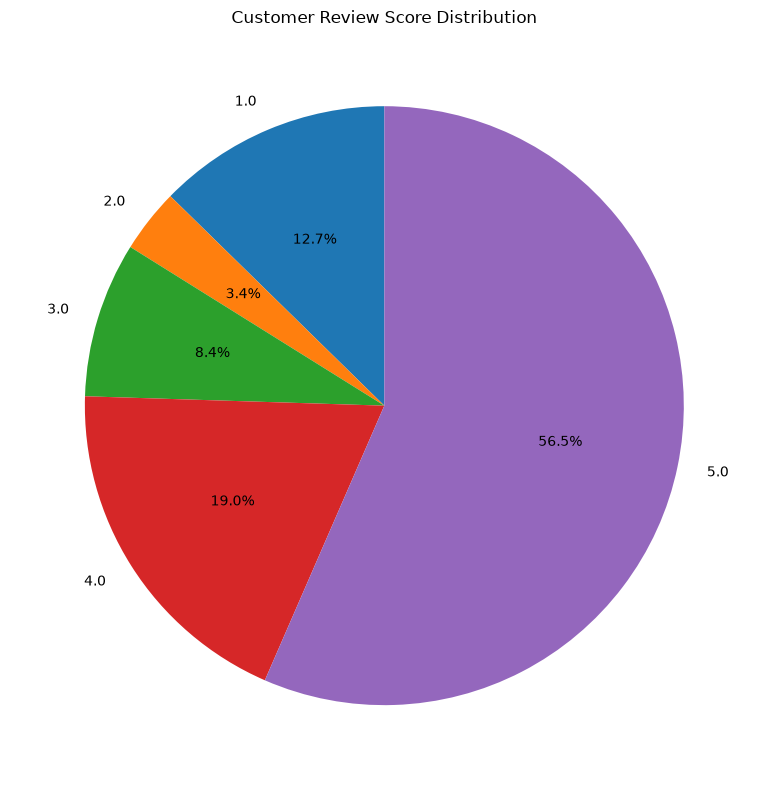

In [21]:
plt.figure(figsize=(8,8))

plt.pie(
    review_distribution,
    labels=review_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Customer Review Score Distribution"
)

plt.tight_layout()

plt.savefig(
    "dashboard/review_score_distribution.png"
)

plt.show()

# Additional Visualization

## Revenue by Product Category Across Months

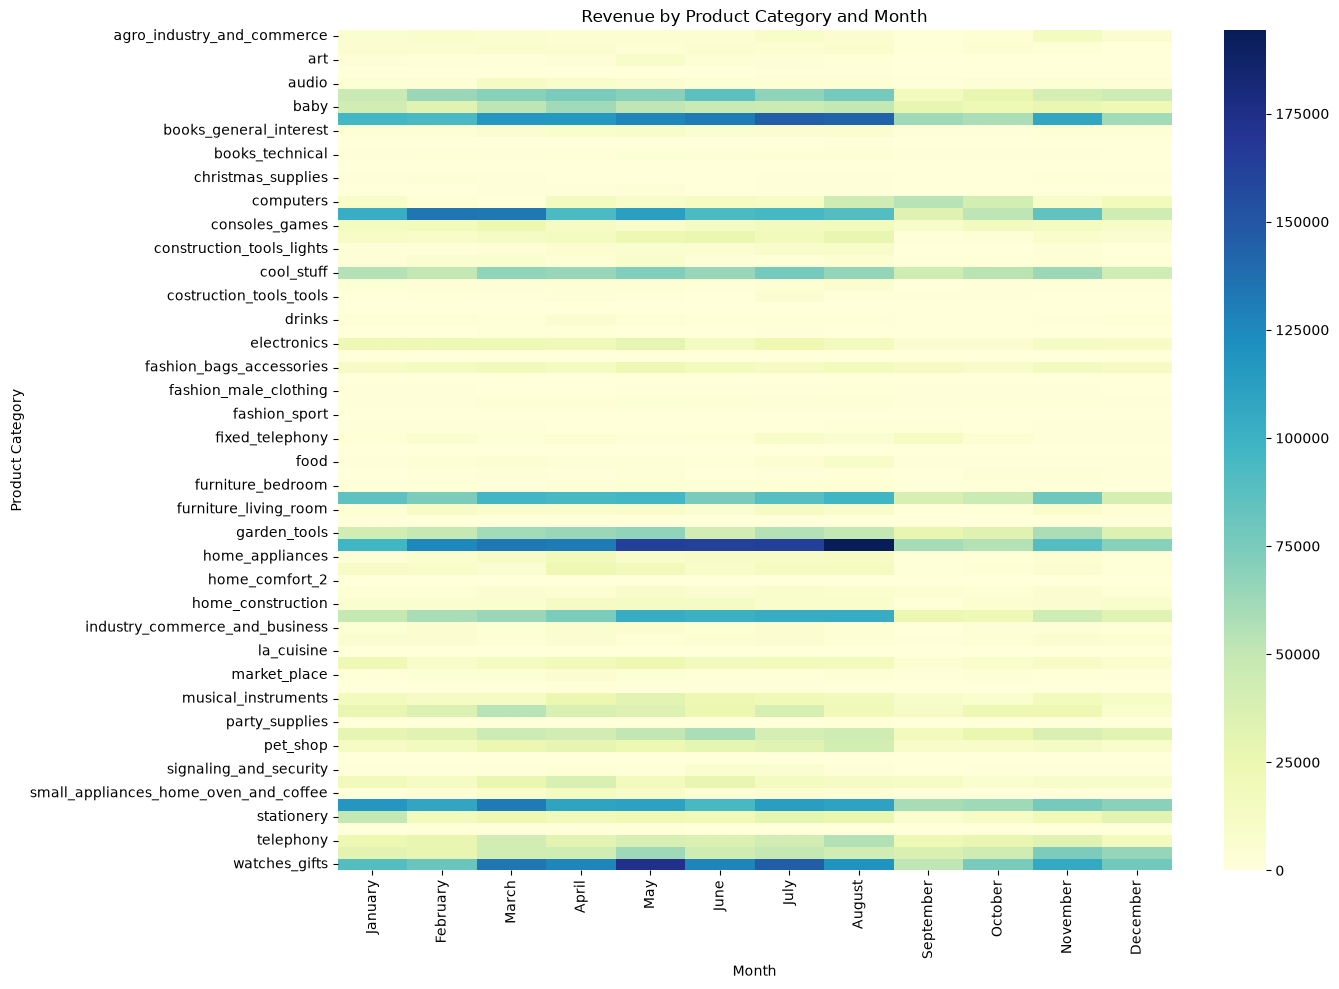

In [22]:
heatmap_data = pd.pivot_table(
    sales,
    values="revenue",
    index="product_category_name_english",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

heatmap_data = heatmap_data.reindex(
    columns=month_order
)

plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title(
    "Revenue by Product Category and Month"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Product Category"
)

plt.tight_layout()

plt.savefig(
    "dashboard/category_month_heatmap.png"
)

plt.show()

# KPI Dashboard

In [23]:
total_revenue = round(
    sales["revenue"].sum(),
    2
)

total_orders = sales["order_id"].nunique()

average_review = round(
    sales["review_score"].mean(),
    2
)

print("\n" + "="*60)
print("KPI DASHBOARD")
print("="*60)

print(f"Total Revenue      : ₹ {total_revenue:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Average Review     : {average_review}")


KPI DASHBOARD
Total Revenue      : ₹ 15,915,872.32
Total Orders       : 98666
Average Review     : 4.03


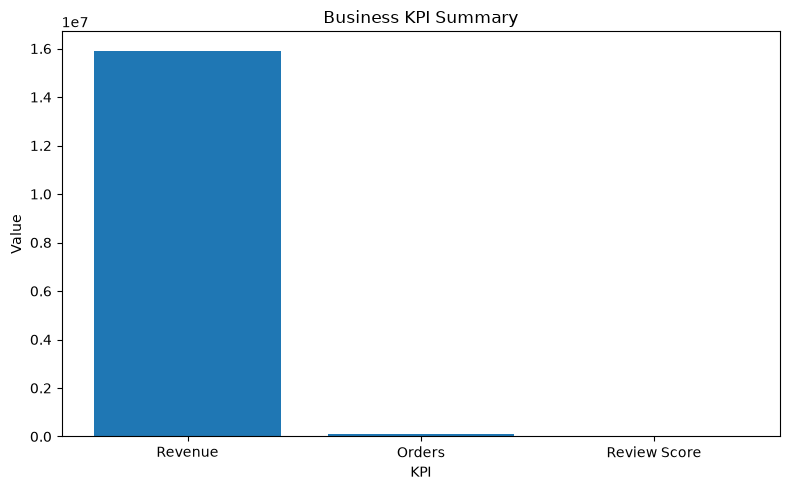

In [24]:
kpi_names = [
    "Revenue",
    "Orders",
    "Review Score"
]

kpi_values = [
    total_revenue,
    total_orders,
    average_review
]

plt.figure(figsize=(8,5))

plt.bar(
    kpi_names,
    kpi_values
)

plt.title(
    "Business KPI Summary"
)

plt.xlabel("KPI")

plt.ylabel("Value")

plt.tight_layout()

plt.show()

# Business Insights Report

## Executive Summary

The e-commerce sales dataset was analyzed to identify sales trends, top-performing product categories, regional performance, customer purchasing behavior, and review patterns. Multiple datasets were combined into a master dataset to generate meaningful business insights. The findings can help businesses improve sales strategies, inventory management, and customer satisfaction.

## Key Business Insights

1. Health & Beauty is the highest revenue-generating product category.
2. Monthly sales show seasonal variations, with some months significantly outperforming others.
3. Certain customer states contribute a much larger share of total revenue.
4. The average order value provides a useful measure of customer spending behavior.
5. Customer review scores are generally positive, indicating good overall customer satisfaction.

# Surprising Finding

One interesting finding from the analysis is that a small number of product categories contribute a disproportionately large share of total revenue. This indicates that focusing marketing efforts and inventory planning on these high-performing categories can significantly improve overall business performance while maintaining customer satisfaction.